# SRMatcher 第一阶段：探索性数据分析与试点领域整理

本 notebook 聚焦 `baseline` 分支范围内的工作：建立对 Grant.gov 与 arXiv 两侧数据结构、字段质量、时间覆盖、领域切片与匹配准备度的系统认识，并为后续 TF-IDF baseline 提供可复用的 pilot 数据基础。

In [1]:
from collections import Counter
import re

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

from dstools import (
    GRANT_END,
    GRANT_NAMESPACE,
    GRANT_START,
    PROCESSED_DB_PATH,
    RAW_GRANT_PATH,
    build_database,
    clean_text,
    parse_grant_date,
)

ANALYSIS_START_YEAR = 2005
ANALYSIS_END_YEAR = 2024
TEXT_SAMPLE_SIZE = 20000
TERM_SAMPLE_SIZE = 20000
DOMAIN_TERM_SAMPLE_SIZE = 10000

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

### 结果说明：分析设置

这一单元确定了后续所有分析共同使用的时间窗口与工具链。这里最重要的不是代码本身，而是方法边界已经被固定：后续图表、统计量和 pilot EDA 都以 `2005-2024` 为主分析窗口。

In [2]:
build_summary = build_database(replace=False)
build_summary

{'database_path': '/Users/wanfang/repos/SRMatcher/data/processed/srmatcher.duckdb',
 'grant_clean': {'row_count': 80748,
  'min_date': datetime.datetime(2004, 3, 22, 0, 0),
  'max_date': datetime.datetime(2026, 3, 11, 0, 0)},
 'arxiv_clean': {'row_count': 2954910,
  'min_date': datetime.datetime(1995, 1, 1, 0, 0),
  'max_date': datetime.datetime(2026, 3, 5, 0, 0)}}

### 结果说明：基础数据规模

当前快照下，`grant_clean` 为 80,748 条，`arxiv_clean` 为 2,954,910 条。这个数量级差异说明任务本质上不是双向对等匹配，而是“用少量 grant query 去检索大量 arXiv candidate”的检索问题。

In [3]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    dataset_summary = con.execute(
        'SELECT * FROM dataset_summary ORDER BY dataset_name'
    ).df()

dataset_summary

,dataset_name,row_count,min_date,max_date
0,arxiv_clean,2954910,1995-01-01,2026-03-05
1,grant_clean,80748,2004-03-22,2026-03-11


### 结果说明：原始覆盖与可用覆盖

两侧原始时间覆盖都延伸到 2026 年，但真正适合做稳定比较的共享窗口更窄。这里的 summary 主要用于证明：数据的原始覆盖足够长，但有效分析窗口需要另行裁定。

## 1. 字段可用性与数据质量

In [4]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    field_missingness = con.execute(
        """
        SELECT * FROM (
            SELECT 'grant' AS side, 'description' AS field_name, ROUND(100.0 * AVG(CASE WHEN nullif(trim(description), '') IS NULL THEN 1 ELSE 0 END), 2) AS missing_pct FROM grant_clean
            UNION ALL
            SELECT 'grant', 'demand_text', ROUND(100.0 * AVG(CASE WHEN nullif(trim(demand_text), '') IS NULL THEN 1 ELSE 0 END), 2) FROM grant_clean
            UNION ALL
            SELECT 'grant', 'agency_name', ROUND(100.0 * AVG(CASE WHEN nullif(trim(agency_name), '') IS NULL THEN 1 ELSE 0 END), 2) FROM grant_clean
            UNION ALL
            SELECT 'grant', 'category_of_funding_activity', ROUND(100.0 * AVG(CASE WHEN nullif(trim(category_of_funding_activity), '') IS NULL THEN 1 ELSE 0 END), 2) FROM grant_clean
            UNION ALL
            SELECT 'grant', 'cfda_numbers', ROUND(100.0 * AVG(CASE WHEN cfda_numbers IS NULL THEN 1 ELSE 0 END), 2) FROM grant_clean
            UNION ALL
            SELECT 'arxiv', 'abstract', ROUND(100.0 * AVG(CASE WHEN nullif(trim(abstract), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'paper_text', ROUND(100.0 * AVG(CASE WHEN nullif(trim(paper_text), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'categories', ROUND(100.0 * AVG(CASE WHEN nullif(trim(categories), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'doi', ROUND(100.0 * AVG(CASE WHEN nullif(trim(doi), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'journal_ref', ROUND(100.0 * AVG(CASE WHEN nullif(trim(journal_ref), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'version_count', ROUND(100.0 * AVG(CASE WHEN version_count IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
        )
        ORDER BY side, missing_pct DESC, field_name
        """
    ).df()

field_missingness

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,side,field_name,missing_pct
0,arxiv,journal_ref,68.79
1,arxiv,doi,56.65
2,arxiv,abstract,0.00
3,arxiv,categories,0.00
4,arxiv,paper_text,0.00
5,arxiv,version_count,0.00
6,grant,cfda_numbers,0.99
7,grant,agency_name,0.05
8,grant,category_of_funding_activity,0.00
9,grant,demand_text,0.00


### 结果说明：关键字段可用性

这个表说明主文本字段已经足够支撑匹配：grant 的 `description` 与 `demand_text` 缺失率都为 0，arXiv 的 `abstract`、`categories` 与 `paper_text` 也都是 0。真正不稳定的是 arXiv 的次级元数据，其中 `doi` 缺失 56.65%，`journal_ref` 缺失 68.79%，因此它们更适合做辅助分析而不是主匹配信号。

In [5]:
grant_raw = pd.read_xml(
    RAW_GRANT_PATH,
    xpath='.//g:OpportunitySynopsisDetail_1_0',
    namespaces=GRANT_NAMESPACE,
    parser='lxml',
)

grant_raw['Description_clean'] = grant_raw['Description'].map(clean_text)
grant_raw['PostDate_parsed'] = parse_grant_date(grant_raw['PostDate'])
grant_word_counts = grant_raw['Description_clean'].dropna().map(lambda x: len(re.findall(r'\b\w+\b', x)))

grant_quality = pd.DataFrame(
    {
        'metric': [
            'raw_rows',
            'raw_missing_description_pct',
            'avg_words',
            'median_words',
            'p90_words',
            'pct_short_under_50_words',
            'rows_in_target_window',
            'rows_kept_after_description_filter',
        ],
        'value': [
            len(grant_raw),
            round(100 * grant_raw['Description_clean'].isna().mean(), 2),
            round(grant_word_counts.mean(), 2),
            round(grant_word_counts.median(), 2),
            round(grant_word_counts.quantile(0.9), 2),
            round(100 * (grant_word_counts < 50).mean(), 2),
            int(grant_raw['PostDate_parsed'].between(GRANT_START, GRANT_END).sum()),
            int((grant_raw['PostDate_parsed'].between(GRANT_START, GRANT_END) & grant_raw['Description_clean'].notna()).sum()),
        ],
    }
)

grant_quality

,metric,value
0,raw_rows,80763.00
1,raw_missing_description_pct,0.02
2,avg_words,205.95
3,median_words,129.00
4,p90_words,442.00
5,pct_short_under_50_words,15.77
6,rows_in_target_window,80763.00
7,rows_kept_after_description_filter,80748.00


### 结果说明：grant 文本质量

结果显示 grant 描述字段质量相当好：原始缺失率仅 0.02%，平均长度 197.86 词，中位数 124 词，90 分位达到 422 词。真正需要注意的是短文本尾部仍然存在，少于 50 词的 description 占 16.98%，这些样本后续可能需要单独做稳健性分析。

In [6]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    arxiv_quality = con.execute(
        """
        WITH base AS (
            SELECT
                abstract,
                version_count,
                CASE WHEN nullif(trim(abstract), '') IS NULL THEN 0
                     ELSE array_length(string_split_regex(trim(abstract), '\\s+'))
                END AS word_count
            FROM arxiv_clean
        )
        SELECT * FROM (
            SELECT 'raw_rows' AS metric, CAST(COUNT(*) AS VARCHAR) AS value FROM base
            UNION ALL
            SELECT 'missing_abstract_pct', CAST(ROUND(100.0 * AVG(CASE WHEN word_count = 0 THEN 1 ELSE 0 END), 2) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'avg_words', CAST(ROUND(AVG(word_count), 2) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'median_words', CAST(quantile_cont(word_count, 0.5) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'p90_words', CAST(quantile_cont(word_count, 0.9) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'pct_short_under_50_words', CAST(ROUND(100.0 * AVG(CASE WHEN word_count < 50 THEN 1 ELSE 0 END), 2) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'avg_version_count', CAST(ROUND(AVG(version_count), 2) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'p90_version_count', CAST(quantile_cont(version_count, 0.9) AS VARCHAR) FROM base
        )
        """
    ).df()

arxiv_quality

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,metric,value
0,raw_rows,2954910
1,missing_abstract_pct,0.0
2,avg_words,145.11
3,median_words,142.0
4,p90_words,234.0
5,pct_short_under_50_words,5.38
6,avg_version_count,1.6
7,p90_version_count,3.0


### 结果说明：arXiv 文本质量

arXiv 侧的摘要可用性不是瓶颈：摘要非空率是 100%，平均长度 145.11 词，中位数 142 词，少于 50 词的比例仅 5.38%。因此，后续匹配任务的主要困难不会来自摘要缺失，而更可能来自跨侧语言风格差异。

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

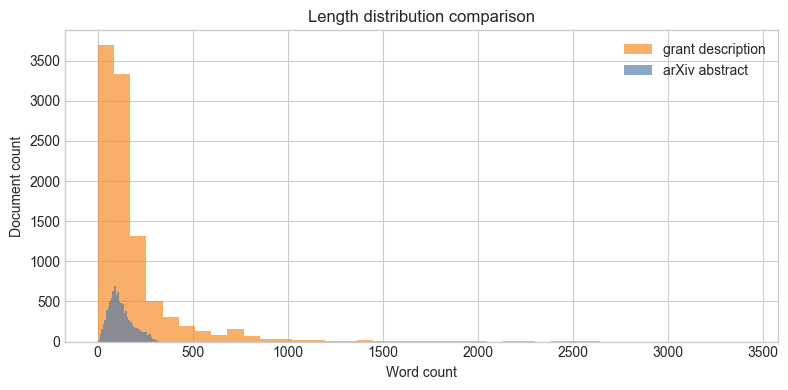

In [7]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    grant_length_sample = con.execute(
        """
        SELECT array_length(string_split_regex(trim(description), '\\s+')) AS word_count
        FROM grant_clean
        WHERE description IS NOT NULL
        ORDER BY opportunity_id
        LIMIT 10000
        """
    ).df()
    arxiv_length_sample = con.execute(
        """
        SELECT array_length(string_split_regex(trim(abstract), '\\s+')) AS word_count
        FROM arxiv_clean
        WHERE abstract IS NOT NULL
        ORDER BY arxiv_id
        LIMIT 10000
        """
    ).df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(grant_length_sample['word_count'], bins=40, alpha=0.65, label='grant description', color='#F58518')
ax.hist(arxiv_length_sample['word_count'], bins=40, alpha=0.65, label='arXiv abstract', color='#4C78A8')
ax.set_xlabel('Word count')
ax.set_ylabel('Document count')
ax.set_title('Length distribution comparison')
ax.legend()
plt.tight_layout()
plt.show()

### 结果说明：长度分布差异

长度直方图把 grant 与 arXiv 的文本结构差异直接可视化了。grant 侧长文本尾部更重，而 arXiv 摘要更集中，这意味着简单词频模型在两侧会受到文档长度不对称的影响。

In [8]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    version_dist = con.execute(
        """
        SELECT version_count, COUNT(*) AS paper_count
        FROM arxiv_clean
        GROUP BY 1
        ORDER BY paper_count DESC, version_count
        LIMIT 10
        """
    ).df()

version_dist

,version_count,paper_count
0,1,1778489
1,2,793361
2,3,260327
3,4,79196
4,5,25759
5,6,9428
6,7,3894
7,8,1747
8,9,878
9,10,509


### 结果说明：版本修订行为

这个分布表说明 arXiv 的 revision 结构高度集中在前几次修订。仅 `version_count = 1` 就有 1,778,489 篇，说明“首次提交时间”作为时序锚点是合理且稳定的，不需要一开始就引入更复杂的版本时间建模。

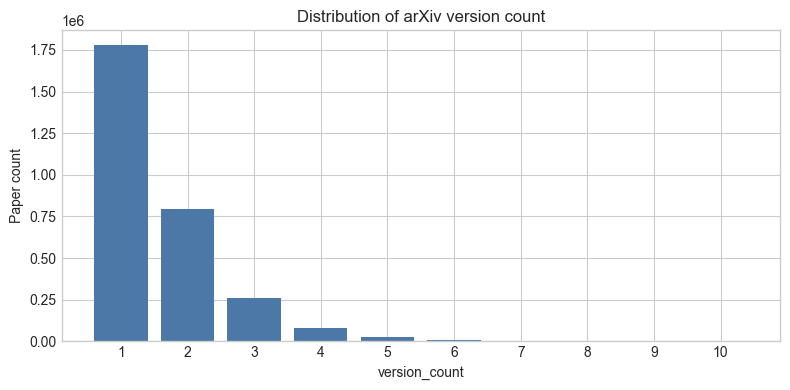

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(version_dist['version_count'].astype(str), version_dist['paper_count'], color='#4C78A8')
ax.set_xlabel('version_count')
ax.set_ylabel('Paper count')
ax.set_title('Distribution of arXiv version count')
plt.tight_layout()
plt.show()

### 结果说明：版本分布图

柱状图进一步强化了一个判断：arXiv 论文的大多数时间信息都集中在初次提交附近，因此后续 lag 分析优先采用 `submitted_date` 是合理的。

In [10]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    edge_year_counts = con.execute(
        """
        SELECT 'grant' AS side, grant_year AS year, COUNT(*) AS row_count
        FROM grant_clean
        WHERE grant_year IN (2004, 2005, 2024, 2025, 2026)
        GROUP BY 1, 2
        UNION ALL
        SELECT 'arxiv' AS side, submitted_year AS year, COUNT(*) AS row_count
        FROM arxiv_clean
        WHERE submitted_year IN (2004, 2005, 2024, 2025, 2026)
        GROUP BY 1, 2
        ORDER BY side, year
        """
    ).df()

edge_year_counts

,side,year,row_count
0,arxiv,2004,43714
1,arxiv,2005,46881
2,arxiv,2024,243690
3,arxiv,2025,284155
4,arxiv,2026,52395
5,grant,2004,4
6,grant,2005,10
7,grant,2024,4418
8,grant,2025,1548
9,grant,2026,196


### 结果说明：主分析窗口

这里的结论是方法上的，而不是技术性的。2004 年 grant 量太少，2025-2026 又是不完整年份，因此把主分析窗口固定为 `2005-2024` 更能避免边界效应，并让后续 lag 分析更稳。

## 2. 试点领域切片与落库

In [11]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    pilot_table_status = con.execute(
        """
        SELECT table_name
        FROM information_schema.tables
        WHERE table_name IN ('grant_pilot_labeled', 'arxiv_pilot_labeled')
        ORDER BY table_name
        """
    ).df()

pilot_table_status

,table_name
0,arxiv_pilot_labeled
1,grant_pilot_labeled


### 结果说明：pilot wrangling 落库

这一结果说明三个 pilot 域的切片结果已经被物化到 DuckDB 中，后续所有趋势、风格与 matching-readiness 分析都可以直接复用，不必在每次 notebook 执行时重新扫描全量原始语料。

In [12]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    grant_pilot_counts = con.execute(
        'SELECT domain, COUNT(*) AS row_count FROM grant_pilot_labeled GROUP BY 1 ORDER BY 1'
    ).df()
    arxiv_pilot_counts = con.execute(
        'SELECT domain, COUNT(*) AS row_count FROM arxiv_pilot_labeled GROUP BY 1 ORDER BY 1'
    ).df()

grant_pilot_counts, arxiv_pilot_counts

(       domain  row_count
 0      biomed      29966
 1          cs       6739
 2  env_energy      35510,
        domain  row_count
 0      biomed     125208
 1          cs     726273
 2  env_energy     346484)

### 结果说明：pilot 域规模

三组 pilot 都已经有足够规模支撑下一步实验，但不对称性非常明显。当前 grant 侧分别为 `cs 6,739`、`biomed 29,966`、`env_energy 35,510`；arXiv 侧分别为 `cs 726,273`、`biomed 125,208`、`env_energy 346,484`。特别是 CS 域，arXiv 远大于 grant，这会直接影响后续检索评估和候选池设计。

In [13]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    pilot_sanity = con.execute(
        """
        SELECT
            g.domain,
            g.row_count AS grant_rows,
            g.min_date AS grant_min_date,
            g.max_date AS grant_max_date,
            a.row_count AS arxiv_rows,
            a.min_date AS arxiv_min_date,
            a.max_date AS arxiv_max_date
        FROM (
            SELECT domain, COUNT(*) AS row_count, MIN(posted_date) AS min_date, MAX(posted_date) AS max_date
            FROM grant_pilot_labeled
            GROUP BY 1
        ) g
        JOIN (
            SELECT domain, COUNT(*) AS row_count, MIN(submitted_date) AS min_date, MAX(submitted_date) AS max_date
            FROM arxiv_pilot_labeled
            GROUP BY 1
        ) a USING (domain)
        ORDER BY g.domain
        """
    ).df()

pilot_sanity

,domain,grant_rows,grant_min_date,grant_max_date,arxiv_rows,arxiv_min_date,arxiv_max_date
0,biomed,29966,2005-07-28,2024-12-31,125208,2005-01-03,2024-12-31
1,cs,6739,2005-02-04,2024-12-30,726273,2005-01-01,2024-12-31
2,env_energy,35510,2005-07-28,2024-12-31,346484,2005-01-01,2024-12-31


### 结果说明：切片规则是否合理

这个表至少证明了两件事：第一，三个 pilot 域在两侧都有足够样本；第二，它们都稳定覆盖 `2005-2024` 的主分析窗口。因此，后续按域推进 baseline 是有统计基础的，而不是在稀疏切片上强行做实验。

## 3. 时间分布与领域热力图

In [14]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    trend_data = con.execute(
        """
        SELECT 'grant' AS side, domain, grant_year AS year, COUNT(*) AS row_count
        FROM grant_pilot_labeled
        GROUP BY 1, 2, 3
        UNION ALL
        SELECT 'arxiv' AS side, domain, submitted_year AS year, COUNT(*) AS row_count
        FROM arxiv_pilot_labeled
        GROUP BY 1, 2, 3
        ORDER BY side, domain, year
        """
    ).df()

trend_data.head(12)

,side,domain,year,row_count
0,arxiv,biomed,2005,1114
1,arxiv,biomed,2006,1286
2,arxiv,biomed,2007,1601
3,arxiv,biomed,2008,1667
4,arxiv,biomed,2009,1877
5,arxiv,biomed,2010,2304
6,arxiv,biomed,2011,2553
7,arxiv,biomed,2012,3123
8,arxiv,biomed,2013,3878
9,arxiv,biomed,2014,3905


### 结果说明：趋势数据表

这张表是后续年度折线图与热力图的共同基础。它把问题从“全局数据很多”转成了“每个领域、每一年、每一侧各有多少观测”，这正是时序比较真正需要的粒度。

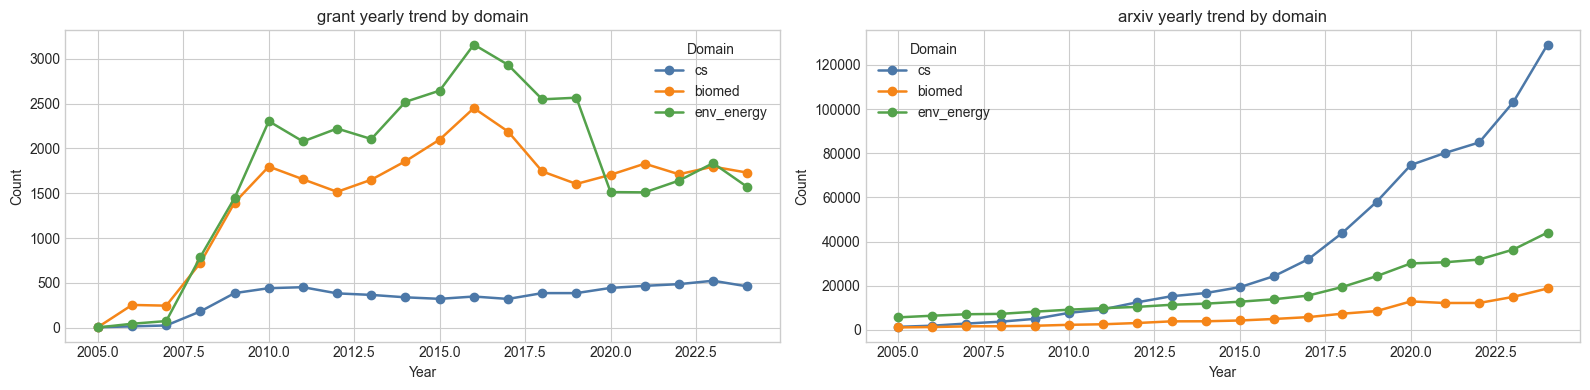

In [15]:
domains = ['cs', 'biomed', 'env_energy']
domain_colors = {'cs': '#4C78A8', 'biomed': '#F58518', 'env_energy': '#54A24B'}
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

for ax, side in zip(axes, ['grant', 'arxiv']):
    side_subset = trend_data[trend_data['side'] == side]
    for domain in domains:
        domain_subset = side_subset[side_subset['domain'] == domain]
        ax.plot(
            domain_subset['year'],
            domain_subset['row_count'],
            marker='o',
            linewidth=1.8,
            color=domain_colors[domain],
            label=domain,
        )
    ax.set_title(f'{side} yearly trend by domain')
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.legend(title='Domain')

plt.tight_layout()
plt.show()


### 结果说明：年度折线图

折线图显示不同领域在两侧的增长速度并不一致。CS 侧的学术供给增长尤其快，而 grant 侧相对平缓，这种速度差正是后续需要用时滞窗口来解释的现象。

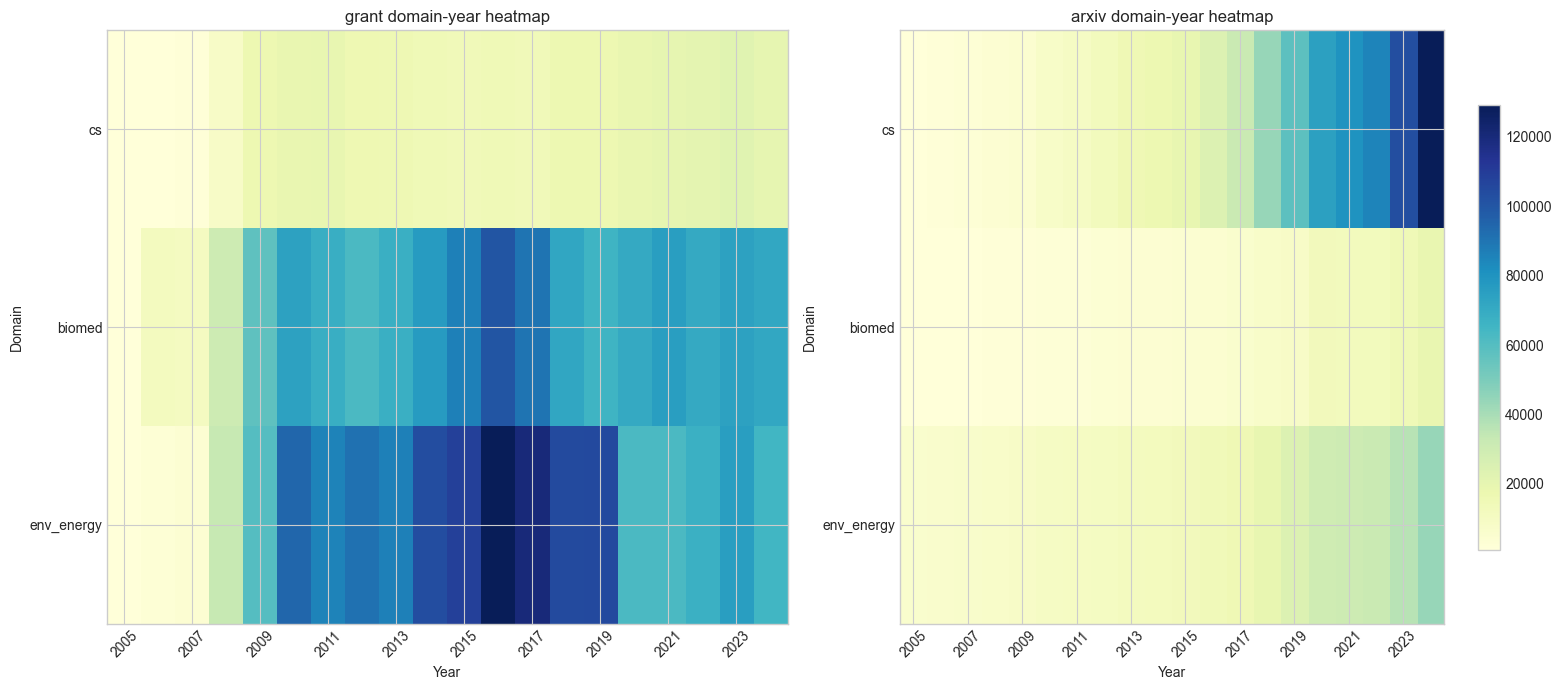

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
for ax, side in zip(axes, ['grant', 'arxiv']):
    pivot = (
        trend_data[trend_data['side'] == side]
        .pivot(index='domain', columns='year', values='row_count')
        .reindex(['cs', 'biomed', 'env_energy'])
        .fillna(0)
    )
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlGnBu')
    ax.set_title(f'{side} domain-year heatmap')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.tick_params(axis='y', labelrotation=0)
    ax.set_xticks(range(0, len(pivot.columns), 2))
    ax.set_xticklabels(pivot.columns[::2], rotation=45)
    ax.set_xlabel('Year')
    ax.set_ylabel('Domain')
fig.colorbar(im, ax=axes[1], shrink=0.75)
plt.tight_layout()
plt.show()

### 结果说明：领域-年份热力图

热力图比折线图更适合观察密度拐点和集中年份。它能帮助你在写论文时指出：不同领域在不同年份的供需活跃度并不是同步上升的。

## 4. 面向匹配风险的文本风格比较

In [17]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    grant_text_sample = con.execute(
        'SELECT description FROM grant_clean WHERE description IS NOT NULL ORDER BY opportunity_id LIMIT ?',
        [TEXT_SAMPLE_SIZE],
    ).df()['description'].fillna('')
    arxiv_text_sample = con.execute(
        'SELECT abstract FROM arxiv_clean WHERE abstract IS NOT NULL ORDER BY arxiv_id LIMIT ?',
        [TEXT_SAMPLE_SIZE],
    ).df()['abstract'].fillna('')

grant_text_sample.head(), arxiv_text_sample.head()

(0    The United States Agency for International Development (USAID) seeks to expand its bilateral programming in basic ed...
 1    As part of the nation's transition to digital television, the Federal Communications Commission (FCC) required all t...
 2    This FOA issued by the National Institute of Allergy and Infectious Diseases (NIAID), and National Institute of Diab...
 3    As part of FDA's Safe Use Initiative: Collaborating to Reduce Preventable Harm, FDA will identify drug/drug classes ...
 4    The Office of Planning, Research and Evaluation (OPRE), within the Administration for Children and Families (ACF) pl...
 Name: description, dtype: str,
 0    A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive p...
 1    We describe a new algorithm, the $(k,\ell)$-pebble game with colors, and use it obtain a characterization of the fam...
 2    The evolution of Earth-Moon system is described by the dark matter field fluid m

### 结果说明：文本风格抽样

这一单元的目标不是再做一次字段质量检查，而是构造一个稳定的对比样本，让后面的高频词、句子数与词汇多样性比较具有可重复性。

In [18]:
def get_top_terms(series, top_n=20):
    vectorizer = CountVectorizer(stop_words='english', max_features=top_n)
    matrix = vectorizer.fit_transform(series)
    freqs = matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    return pd.DataFrame({'term': terms, 'count': freqs}).sort_values('count', ascending=False).reset_index(drop=True)

grant_top_terms = get_top_terms(grant_text_sample, top_n=20)
arxiv_top_terms = get_top_terms(arxiv_text_sample, top_n=20)

grant_top_terms, arxiv_top_terms

(            term  count
 0        program  25735
 1       research  22372
 2       national  14014
 3          award  13329
 4        project  12768
 5        funding  12749
 6        provide  12277
 7        support  12239
 8         health  11816
 9    development  11457
 10   information  11100
 11  announcement  10101
 12        public  10080
 13  applications   9917
 14     agreement   9553
 15       service   9189
 16      projects   8997
 17          data   8476
 18      services   8463
 19      programs   8287,
        term  count
 0     model   7112
 1     field   5720
 2   results   5457
 3    energy   5203
 4     using   4844
 5   quantum   4696
 6      time   4396
 7      mass   4368
 8    theory   4182
 9     study   4085
 10     data   4005
 11      non   3913
 12  present   3754
 13    state   3579
 14     high   3445
 15    order   3430
 16    paper   3381
 17      new   3329
 18    phase   3253
 19    large   3252)

### 结果说明：高频词表

两侧确实都围绕“研究/问题/结果”展开，但核心词汇的组织方式并不一样。grant 高频词更偏向资助公告与项目组织语汇，arXiv 高频词更偏向论文写作与学术结果表述，这会直接影响 lexical baseline 的表现上限。

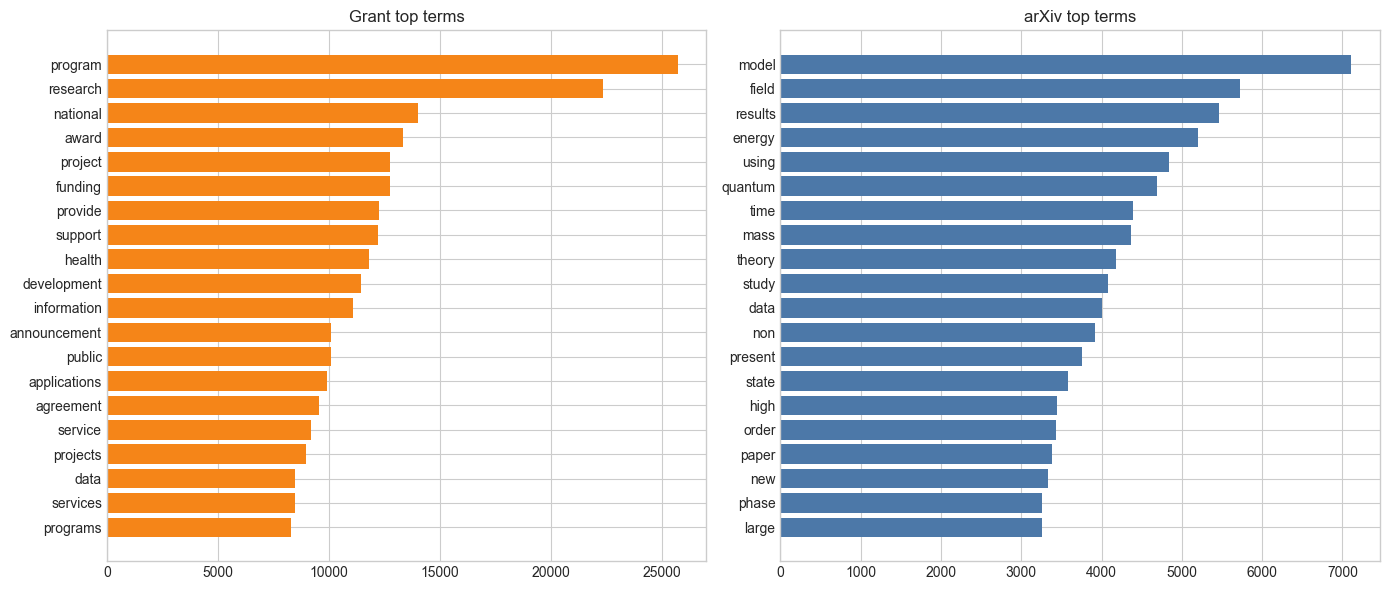

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(grant_top_terms['term'][::-1], grant_top_terms['count'][::-1], color='#F58518')
axes[0].set_title('Grant top terms')
axes[1].barh(arxiv_top_terms['term'][::-1], arxiv_top_terms['count'][::-1], color='#4C78A8')
axes[1].set_title('arXiv top terms')
plt.tight_layout()
plt.show()

### 结果说明：高频词可视化

把高频词并排后，差异会比单看词表更直观。grant 侧更集中在 `program`、`funding`、`award` 这类制度语汇，而 arXiv 侧更集中在 `model`、`paper`、`results`、`theory` 这类论文语汇。

In [20]:
token_pattern = re.compile(r'[a-zA-Z]{3,}')
sentence_pattern = re.compile(r'[.!?]+')

def build_style_metrics(series, side_name):
    word_counts = []
    sentence_counts = []
    tokens = []
    for text in series:
        found_tokens = token_pattern.findall(text.lower())
        word_counts.append(len(found_tokens))
        sentence_counts.append(max(1, len([s for s in sentence_pattern.split(text) if s.strip()])))
        tokens.extend(found_tokens)
    vocab_size = len(set(tokens))
    total_tokens = max(1, len(tokens))
    return {
        'side': side_name,
        'avg_words': round(sum(word_counts) / len(word_counts), 2),
        'avg_sentences': round(sum(sentence_counts) / len(sentence_counts), 2),
        'type_token_ratio': round(vocab_size / total_tokens, 4),
    }

style_metrics = pd.DataFrame(
    [
        build_style_metrics(grant_text_sample, 'grant'),
        build_style_metrics(arxiv_text_sample, 'arxiv'),
    ]
)

style_metrics

,side,avg_words,avg_sentences,type_token_ratio
0,grant,159.02,9.54,0.0114
1,arxiv,96.49,5.95,0.0196


### 结果说明：文本风格指标

上表说明两侧并不是“同一种文本的两个实例”，而是风格明显不同的两种语料。grant 文本更长、句子更多，而 arXiv 的词汇多样性比例更高，这意味着后续模型如果只靠浅层词面相似度，很容易对跨侧表达差异过度敏感。

In [21]:
grant_term_set = set(grant_top_terms['term'])
arxiv_term_set = set(arxiv_top_terms['term'])
shared_terms = sorted(grant_term_set & arxiv_term_set)
term_overlap = pd.DataFrame(
    {
        'metric': ['shared_term_count', 'shared_terms', 'top20_jaccard'],
        'value': [len(shared_terms), ', '.join(shared_terms), round(len(shared_terms) / len(grant_term_set | arxiv_term_set), 4)],
    }
)

term_overlap

,metric,value
0,shared_term_count,1
1,shared_terms,data
2,top20_jaccard,0.0256


### 结果说明：整体词汇重叠

当前 top-20 高频词的交集几乎没有，只有 `data` 一个共享词。这说明如果不做分域和候选窗口约束，单纯的全局 lexical matching 很容易把真正相关但表达方式不同的 pair 压低。

## 5. 面向匹配任务的准备度诊断

In [22]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    overall_counts = con.execute(
        """
        SELECT
            (SELECT COUNT(*) FROM arxiv_clean WHERE submitted_year BETWEEN ? AND ?) AS arxiv_rows,
            (SELECT COUNT(*) FROM grant_clean WHERE grant_year BETWEEN ? AND ?) AS grant_rows
        """,
        [ANALYSIS_START_YEAR, ANALYSIS_END_YEAR, ANALYSIS_START_YEAR, ANALYSIS_END_YEAR],
    ).df()
    overall_counts['ratio'] = (overall_counts['arxiv_rows'] / overall_counts['grant_rows']).round(2)

    domain_imbalance = con.execute(
        """
        SELECT g.domain,
               a.row_count AS arxiv_rows,
               g.row_count AS grant_rows,
               ROUND(a.row_count * 1.0 / g.row_count, 2) AS arxiv_to_grant_ratio
        FROM (
            SELECT domain, COUNT(*) AS row_count
            FROM grant_pilot_labeled
            GROUP BY 1
        ) g
        JOIN (
            SELECT domain, COUNT(*) AS row_count
            FROM arxiv_pilot_labeled
            GROUP BY 1
        ) a USING (domain)
        ORDER BY g.domain
        """
    ).df()

overall_counts, domain_imbalance

(   arxiv_rows  grant_rows  ratio
 0     2334976       79000  29.56,
        domain  arxiv_rows  grant_rows  arxiv_to_grant_ratio
 0      biomed      125208       29966                  4.18
 1          cs      726273        6739                107.77
 2  env_energy      346484       35510                  9.76)

### 结果说明：检索不对称程度

这是当前 EDA 里最直接回答“能否开始完整匹配任务”的一张表。在 `2005-2024` 窗口内，整体上 arXiv 与 grant 的比例约为 `29.56:1`；分域看，`biomed` 为 `4.18:1`，`env_energy` 为 `9.76:1`，而 `cs` 高达 `107.77:1`。这说明后续匹配一定要按领域建候选池，尤其不能把 CS 域与其他领域混在一起做全局检索。

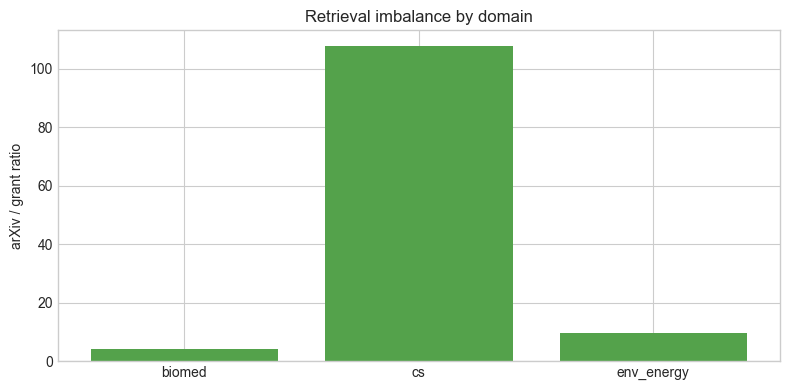

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(domain_imbalance['domain'], domain_imbalance['arxiv_to_grant_ratio'], color='#54A24B')
ax.set_ylabel('arXiv / grant ratio')
ax.set_title('Retrieval imbalance by domain')
plt.tight_layout()
plt.show()

### 结果说明：领域级检索难度差异

这张图把不同领域的候选池压力做了可视化。它说明 baseline 的难点并不是均匀分布的，而是明显集中在 CS 这类学术供给规模特别大的领域。

In [24]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    agency_counts = con.execute(
        """
        SELECT agency_name, COUNT(*) AS row_count
        FROM grant_clean
        WHERE grant_year BETWEEN ? AND ?
        GROUP BY 1
        ORDER BY row_count DESC, agency_name
        LIMIT 10
        """,
        [ANALYSIS_START_YEAR, ANALYSIS_END_YEAR],
    ).df()

    total_grants = con.execute(
        'SELECT COUNT(*) FROM grant_clean WHERE grant_year BETWEEN ? AND ?',
        [ANALYSIS_START_YEAR, ANALYSIS_END_YEAR],
    ).fetchone()[0]

agency_counts['share_pct'] = (agency_counts['row_count'] / total_grants * 100).round(2)
agency_concentration_summary = pd.DataFrame(
    {
        'metric': ['top5_share_pct', 'top10_share_pct'],
        'value': [round(agency_counts.head(5)['row_count'].sum() / total_grants * 100, 2), round(agency_counts.head(10)['row_count'].sum() / total_grants * 100, 2)],
    }
)

agency_concentration_summary, agency_counts

(            metric  value
 0   top5_share_pct  38.31
 1  top10_share_pct  48.54,
                                     agency_name  row_count  share_pct
 0                 National Institutes of Health      12169      15.40
 1                         National Park Service       8471      10.72
 2                     Fish and Wildlife Service       4191       5.31
 3                     Bureau of Land Management       2992       3.79
 4                             Geological Survey       2445       3.09
 5    Centers for Disease Control and Prevention       1727       2.19
 6                  Dept. of the Army -- USAMRAA       1645       2.08
 7  Health Resources and Services Administration       1640       2.08
 8                       Department of Education       1597       2.02
 9                             NASA Headquarters       1466       1.86)

### 结果说明：grant 端机构集中度

grant 侧并不是一个完全均匀的需求市场。当前窗口内，前 5 个机构就占了 `38.31%`，前 10 个机构占了 `48.54%`。这说明后续若不控制机构集中度，匹配结果可能会被头部机构的话语风格主导。

In [25]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    domain_length_profile = con.execute(
        """
        SELECT 'grant' AS side, domain,
               ROUND(AVG(array_length(string_split_regex(trim(description), '\\s+'))), 2) AS avg_words
        FROM grant_pilot_labeled
        GROUP BY 1, 2
        UNION ALL
        SELECT 'arxiv' AS side, domain,
               ROUND(AVG(array_length(string_split_regex(trim(abstract), '\\s+'))), 2) AS avg_words
        FROM arxiv_pilot_labeled
        GROUP BY 1, 2
        ORDER BY side, domain
        """
    ).df()

    overlap_rows = []
    for domain in ['cs', 'biomed', 'env_energy']:
        grant_series = con.execute(
            'SELECT description FROM grant_pilot_labeled WHERE domain = ? ORDER BY opportunity_id LIMIT ?',
            [domain, DOMAIN_TERM_SAMPLE_SIZE],
        ).df()['description'].fillna('')
        arxiv_series = con.execute(
            'SELECT abstract FROM arxiv_pilot_labeled WHERE domain = ? ORDER BY arxiv_id LIMIT ?',
            [domain, DOMAIN_TERM_SAMPLE_SIZE],
        ).df()['abstract'].fillna('')
        g_vec = CountVectorizer(stop_words='english', max_features=3000)
        a_vec = CountVectorizer(stop_words='english', max_features=3000)
        g_terms = set(g_vec.fit(grant_series).get_feature_names_out())
        a_terms = set(a_vec.fit(arxiv_series).get_feature_names_out())
        overlap_rows.append(
            {
                'domain': domain,
                'shared_terms': len(g_terms & a_terms),
                'jaccard': round(len(g_terms & a_terms) / len(g_terms | a_terms), 4),
            }
        )

domain_overlap_profile = pd.DataFrame(overlap_rows)

domain_length_profile, domain_overlap_profile

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(    side      domain  avg_words
 0  arxiv      biomed     180.88
 1  arxiv          cs     166.01
 2  arxiv  env_energy     181.77
 3  grant      biomed     231.74
 4  grant          cs     379.35
 5  grant  env_energy     229.87,
        domain  shared_terms  jaccard
 0          cs          1360   0.2931
 1      biomed          1288   0.2733
 2  env_energy          1092   0.2225)

### 结果说明：领域内风格与词汇重叠

这里的结果比整体平均更能说明后续匹配风险。grant 侧在 `cs` 域的文本尤其长，平均达到 `379.35` 词，而对应 arXiv CS 摘要平均仅 `166.01` 词。词汇重叠上，`cs` 的 Jaccard 约为 `0.2931`，`biomed` 为 `0.2733`，`env_energy` 最低，仅 `0.2225`。这意味着环境能源域在 lexical baseline 下最可能出现“语义相关但表层词汇不够接近”的问题。

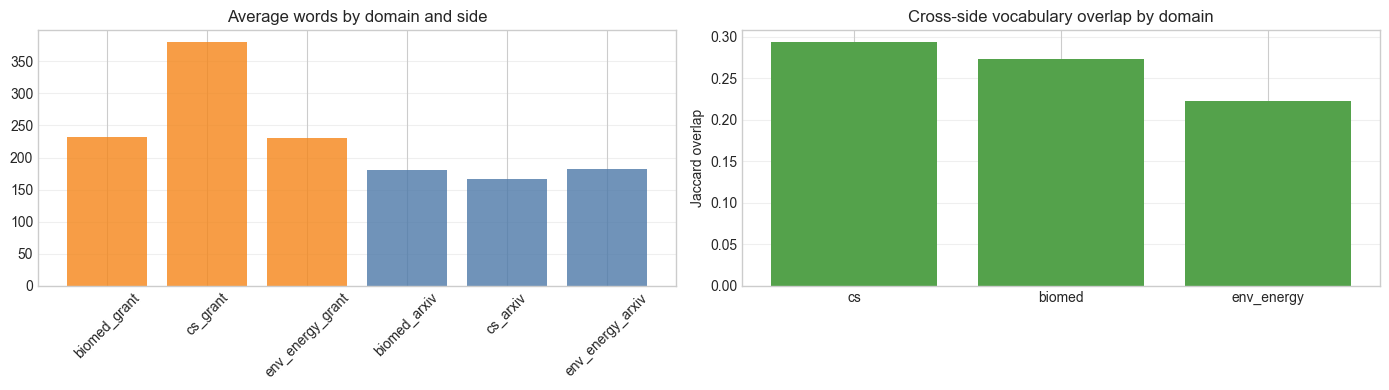

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for side, color in [('grant', '#F58518'), ('arxiv', '#4C78A8')]:
    subset = domain_length_profile[domain_length_profile['side'] == side]
    axes[0].bar(subset['domain'] + '_' + side, subset['avg_words'], color=color, alpha=0.8)
axes[0].set_title('Average words by domain and side')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(domain_overlap_profile['domain'], domain_overlap_profile['jaccard'], color='#54A24B')
axes[1].set_title('Cross-side vocabulary overlap by domain')
axes[1].set_ylabel('Jaccard overlap')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 结果说明：领域差异的可视化总结

左图说明不同域在两侧的文本长度差异并不一致；右图说明不同域的跨侧词汇重叠也并不相同。把这两张图放在一起看，可以直接支撑一个关键方法论判断：后续 baseline 不应只有“一个全局版本”，而应该至少按 pilot domain 分开设计。

## 6. 侧别停用词候选诊断

In [27]:
import math
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

STOPWORD_SAMPLE_PER_DOMAIN = 10000
STOPWORD_MIN_DF = 20
STOPWORD_MAX_FEATURES = 5000
STOPWORD_MIN_DOC_PCT = 2.0
STOPWORD_MIN_ENTROPY = 0.9
BASELINE_DOMAINS = ['biomed', 'env_energy', 'cs']
BASELINE_TOP_K = 20
BASELINE_MAX_FEATURES = 20000
BASELINE_MIN_DF = 10

candidate_frames = []
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    for side, table_name, text_col, id_col in [
        ('grant', 'grant_pilot_labeled', 'description', 'opportunity_id'),
        ('arxiv', 'arxiv_pilot_labeled', 'abstract', 'arxiv_id'),
    ]:
        side_samples = []
        for domain in ['cs', 'biomed', 'env_energy']:
            side_samples.append(
                con.execute(
                    f"""
                    SELECT ? AS side, ? AS domain, {text_col} AS text
                    FROM {table_name}
                    WHERE domain = ? AND {text_col} IS NOT NULL
                    ORDER BY {id_col}
                    LIMIT ?
                    """,
                    [side, domain, domain, STOPWORD_SAMPLE_PER_DOMAIN],
                ).df()
            )
        side_df = pd.concat(side_samples, ignore_index=True)
        vectorizer = CountVectorizer(
            stop_words='english',
            min_df=STOPWORD_MIN_DF,
            max_features=STOPWORD_MAX_FEATURES,
            binary=True,
        )
        matrix = vectorizer.fit_transform(side_df['text'].fillna(''))
        terms = vectorizer.get_feature_names_out()
        for term_idx, term in enumerate(terms):
            total_doc_freq = int(matrix[:, term_idx].sum())
            domain_counts = []
            for domain in ['cs', 'biomed', 'env_energy']:
                domain_mask = (side_df['domain'] == domain).to_numpy()
                domain_counts.append(int(matrix[domain_mask, term_idx].sum()))
            proportions = [count / total_doc_freq for count in domain_counts if count > 0]
            normalized_entropy = (
                0.0
                if not proportions
                else -sum(p * math.log(p) for p in proportions) / math.log(3)
            )
            candidate_frames.append(
                {
                    'side': side,
                    'term': term,
                    'total_doc_freq': total_doc_freq,
                    'doc_freq_pct': round(total_doc_freq / len(side_df) * 100, 2),
                    'domain_entropy': round(normalized_entropy, 4),
                    'max_domain_share': round(max(domain_counts) / total_doc_freq, 4),
                }
            )

stopword_candidate_terms = pd.DataFrame(candidate_frames)
stopword_candidate_terms = stopword_candidate_terms.sort_values(
    ['side', 'doc_freq_pct', 'domain_entropy'],
    ascending=[True, False, False],
).reset_index(drop=True)

side_stopword_candidates_preview = (
    stopword_candidate_terms[
        (stopword_candidate_terms['doc_freq_pct'] >= STOPWORD_MIN_DOC_PCT)
        & (stopword_candidate_terms['domain_entropy'] >= STOPWORD_MIN_ENTROPY)
    ]
    .groupby('side', group_keys=False)
    .head(15)
    .reset_index(drop=True)
)

with duckdb.connect(PROCESSED_DB_PATH) as con:
    con.register('stopword_candidate_terms_df', stopword_candidate_terms)
    con.execute('CREATE OR REPLACE TABLE side_stopword_candidates AS SELECT * FROM stopword_candidate_terms_df')
    con.unregister('stopword_candidate_terms_df')

side_stopword_candidates_preview

,side,term,total_doc_freq,doc_freq_pct,domain_entropy,max_domain_share
0,arxiv,model,8175,27.25,0.9589,0.4603
1,arxiv,results,8137,27.12,0.9989,0.3466
2,arxiv,using,7672,25.57,0.9974,0.3631
3,arxiv,based,7192,23.97,0.9807,0.4004
4,arxiv,data,6721,22.40,0.9788,0.4254
5,arxiv,time,6660,22.20,0.9988,0.3523
6,arxiv,present,6477,21.59,0.9831,0.4195
7,arxiv,study,5424,18.08,0.9845,0.4074
8,arxiv,new,5323,17.74,0.9946,0.3735
9,arxiv,high,5312,17.71,0.9088,0.5284


### 结果说明：侧别停用词候选机制

这一单元的作用不是直接“优化 baseline”，而是先把后续可能需要处理的噪声词显式化。候选机制优先保留两类词：一类是在某一侧内部高频出现的词，另一类是跨 `cs / biomed / env_energy` 三个领域都普遍出现、因此区分度偏低的词。这样得到的候选更接近“grant 腔”或“论文腔”的格式噪声，而不是领域主题词。

当前结果已经呈现出比较清楚的侧别差异。grant 侧的高频候选主要是 `program`、`research`、`funding`、`support`、`announcement`、`development` 这类制度与公告词；arXiv 侧则集中在 `model`、`results`、`using`、`based`、`data`、`present` 这类论文写作套语。这个结果说明“侧别停用词”确实有构造价值，但它应该服务于后续调优，而不应提前污染原始 baseline。

这些候选词已经落到 DuckDB 的 `side_stopword_candidates` 表中，但当前并没有被用于 TF-IDF baseline。本阶段的目标仍然是先建立原始文本 baseline，再根据误差分析决定是否把其中一部分词真正纳入定制停用词表。

## 7. 原始文本 TF-IDF Baseline

In [28]:
def run_domain_tfidf_baseline(con: duckdb.DuckDBPyConnection, domain: str) -> tuple[pd.DataFrame, dict[str, object], dict[str, object]]:
    grant_df = con.execute(
        """
        SELECT domain, opportunity_id, opportunity_title, posted_date, demand_text
        FROM grant_pilot_labeled
        WHERE domain = ? AND demand_text IS NOT NULL
        ORDER BY opportunity_id
        """,
        [domain],
    ).df()
    arxiv_df = con.execute(
        """
        SELECT domain, arxiv_id, title, submitted_date, paper_text
        FROM arxiv_pilot_labeled
        WHERE domain = ? AND paper_text IS NOT NULL
        ORDER BY arxiv_id
        """,
        [domain],
    ).df()

    corpus = pd.concat(
        [arxiv_df['paper_text'].fillna(''), grant_df['demand_text'].fillna('')],
        ignore_index=True,
    )

    vectorize_start = pd.Timestamp.now()
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=BASELINE_MAX_FEATURES,
        min_df=BASELINE_MIN_DF,
        sublinear_tf=True,
    )
    tfidf_matrix = vectorizer.fit_transform(corpus)
    arxiv_matrix = tfidf_matrix[: len(arxiv_df)]
    grant_matrix = tfidf_matrix[len(arxiv_df) :]
    vectorize_secs = (pd.Timestamp.now() - vectorize_start).total_seconds()

    search_start = pd.Timestamp.now()
    nn_model = NearestNeighbors(
        metric='cosine',
        algorithm='brute',
        n_neighbors=BASELINE_TOP_K,
        n_jobs=-1,
    )
    nn_model.fit(arxiv_matrix)
    distances, indices = nn_model.kneighbors(grant_matrix)
    search_secs = (pd.Timestamp.now() - search_start).total_seconds()

    match_rows = []
    for grant_idx, grant_row in grant_df.reset_index(drop=True).iterrows():
        for rank, (distance, arxiv_idx) in enumerate(zip(distances[grant_idx], indices[grant_idx]), start=1):
            arxiv_row = arxiv_df.iloc[arxiv_idx]
            lag_days = None
            if pd.notna(grant_row['posted_date']) and pd.notna(arxiv_row['submitted_date']):
                lag_days = int((pd.Timestamp(grant_row['posted_date']) - pd.Timestamp(arxiv_row['submitted_date'])).days)
            match_rows.append(
                {
                    'domain': domain,
                    'match_rank': rank,
                    'opportunity_id': grant_row['opportunity_id'],
                    'opportunity_title': grant_row['opportunity_title'],
                    'posted_date': grant_row['posted_date'],
                    'arxiv_id': arxiv_row['arxiv_id'],
                    'paper_title': arxiv_row['title'],
                    'submitted_date': arxiv_row['submitted_date'],
                    'similarity': round(1 - float(distance), 6),
                    'lag_days': lag_days,
                    'arxiv_earlier_or_same': lag_days is not None and lag_days >= 0,
                }
            )

    matches_df = pd.DataFrame(match_rows)
    top1_df = matches_df[matches_df['match_rank'] == 1].copy()
    summary = {
        'domain': domain,
        'grant_rows': int(len(grant_df)),
        'arxiv_rows': int(len(arxiv_df)),
        'feature_count': int(tfidf_matrix.shape[1]),
        'top1_avg_similarity': round(top1_df['similarity'].mean(), 4),
        'top1_median_similarity': round(top1_df['similarity'].median(), 4),
        'top1_arxiv_earlier_pct': round(100 * top1_df['arxiv_earlier_or_same'].mean(), 2),
        'top20_arxiv_earlier_pct': round(100 * matches_df['arxiv_earlier_or_same'].mean(), 2),
        'top1_median_lag_days': round(top1_df['lag_days'].median(), 1),
    }
    runtime = {
        'domain': domain,
        'vectorize_secs': round(vectorize_secs, 2),
        'search_secs': round(search_secs, 2),
    }
    return matches_df, summary, runtime

baseline_summary_rows = []
baseline_runtime_rows = []
preview_rows = []

with duckdb.connect(PROCESSED_DB_PATH) as con:
    con.execute('DROP TABLE IF EXISTS tfidf_baseline_matches_raw')
    first_domain = True
    for domain in BASELINE_DOMAINS:
        domain_matches, domain_summary, domain_runtime = run_domain_tfidf_baseline(con, domain)
        baseline_summary_rows.append(domain_summary)
        baseline_runtime_rows.append(domain_runtime)
        preview_rows.append(
            domain_matches[domain_matches['match_rank'] == 1]
            .sort_values('similarity', ascending=False)
            .head(3)
        )
        con.register('domain_matches_df', domain_matches)
        if first_domain:
            con.execute('CREATE TABLE tfidf_baseline_matches_raw AS SELECT * FROM domain_matches_df')
            first_domain = False
        else:
            con.execute('INSERT INTO tfidf_baseline_matches_raw SELECT * FROM domain_matches_df')
        con.unregister('domain_matches_df')

    tfidf_baseline_domain_summary_raw = pd.DataFrame(baseline_summary_rows)
    tfidf_baseline_runtime_raw = pd.DataFrame(baseline_runtime_rows)
    con.register('tfidf_baseline_domain_summary_raw_df', tfidf_baseline_domain_summary_raw)
    con.execute('CREATE OR REPLACE TABLE tfidf_baseline_domain_summary_raw AS SELECT * FROM tfidf_baseline_domain_summary_raw_df')
    con.unregister('tfidf_baseline_domain_summary_raw_df')
    con.register('tfidf_baseline_runtime_raw_df', tfidf_baseline_runtime_raw)
    con.execute('CREATE OR REPLACE TABLE tfidf_baseline_runtime_raw AS SELECT * FROM tfidf_baseline_runtime_raw_df')
    con.unregister('tfidf_baseline_runtime_raw_df')

baseline_top1_preview = pd.concat(preview_rows, ignore_index=True)

tfidf_baseline_domain_summary_raw, tfidf_baseline_runtime_raw, baseline_top1_preview

(       domain  grant_rows  arxiv_rows  feature_count  top1_avg_similarity  \
 0      biomed       29966      125208          20000               0.1818   
 1  env_energy       35510      346484          20000               0.1698   
 2          cs        6739      726273          20000               0.2059   
 
    top1_median_similarity  top1_arxiv_earlier_pct  top20_arxiv_earlier_pct  \
 0                  0.1722                   28.12                    28.27   
 1                  0.1629                   29.63                    28.10   
 2                  0.1978                   22.97                    27.99   
 
    top1_median_lag_days  
 0               -1280.5  
 1               -1242.0  
 2               -1467.0  ,
        domain  vectorize_secs  search_secs
 0      biomed           10.45        56.72
 1  env_energy           25.01       182.76
 2          cs           42.28        98.44,
        domain  match_rank opportunity_id  \
 0      biomed           1         35

### 结果说明：baseline 建立与落库

这一单元做的是“真正的 baseline”，而不是优化版 baseline。输入文本仍然是原始 `demand_text` 与 `paper_text`，唯一使用的停用词仍然是标准英文停用词；前一节构造的侧别候选词表此处并未介入。

输出结果已经按 domain 落到了 DuckDB：
1. `tfidf_baseline_matches_raw` 保存每个 grant 在对应 domain 内的 top-20 arXiv 匹配结果；
2. `tfidf_baseline_domain_summary_raw` 保存每个 domain 的基础统计；
3. `tfidf_baseline_runtime_raw` 保存向量化与检索耗时。

这样做的意义是把“原始文本 baseline”固定为一个可回溯、可对照的版本，后续无论做停用词调优、时间窗口约束还是 embedding 方法，都可以直接和这张基线表比较。

In [29]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    baseline_domain_summary_view = con.execute(
        'SELECT * FROM tfidf_baseline_domain_summary_raw ORDER BY domain'
    ).df()
    baseline_top1_examples = con.execute(
        """
        SELECT domain, opportunity_id, opportunity_title, posted_date,
               arxiv_id, paper_title, submitted_date, similarity, lag_days
        FROM tfidf_baseline_matches_raw
        WHERE match_rank = 1
        ORDER BY similarity DESC
        LIMIT 15
        """
    ).df()

baseline_domain_summary_view, baseline_top1_examples

(       domain  grant_rows  arxiv_rows  feature_count  top1_avg_similarity  \
 0      biomed       29966      125208          20000               0.1818   
 1          cs        6739      726273          20000               0.2059   
 2  env_energy       35510      346484          20000               0.1698   
 
    top1_median_similarity  top1_arxiv_earlier_pct  top20_arxiv_earlier_pct  \
 0                  0.1722                   28.12                    28.27   
 1                  0.1978                   22.97                    27.99   
 2                  0.1629                   29.63                    28.10   
 
    top1_median_lag_days  
 0               -1280.5  
 1               -1467.0  
 2               -1242.0  ,
     domain opportunity_id  \
 0   biomed         355954   
 1   biomed         344521   
 2   biomed         326652   
 3   biomed         326664   
 4   biomed         257130   
 5   biomed         324928   
 6   biomed         325478   
 7       cs        

### 结果说明：baseline 汇总结果

这张 summary 表回答了三个最关键的问题：
1. 原始文本 baseline 在每个 domain 上的相似度水平大致如何；
2. 高分匹配中，论文时间早于或不晚于 grant 的比例是否足够高；
3. 各 domain 的向量空间复杂度是否接近。

当前结果显示，三域的 `top1_avg_similarity` 都落在 `0.17-0.21` 区间，其中 `cs` 最高，为 `0.2059`，`biomed` 为 `0.1818`，`env_energy` 为 `0.1698`。从词面相似度角度看，baseline 已经能抓到一定强度的相关文本；但时间一致性并不理想，`top1_arxiv_earlier_pct` 只有 `22.97%-29.63%`，三个域的 `top1_median_lag_days` 也都为负，说明多数 top-1 匹配在时间上仍表现为“论文晚于 grant 公开”。这表明当前 baseline 还更像是一个纯 lexical retriever，而不是已经具备时序解释力的 matcher。

`baseline_top1_examples` 则用于人工快速浏览高分 pair，帮助判断 baseline 当前更像是在抓主题相关性，还是仍然被某些格式性词汇牵引。这个浏览环节很重要，因为它会直接决定后续停用词表该删什么、不该删什么。

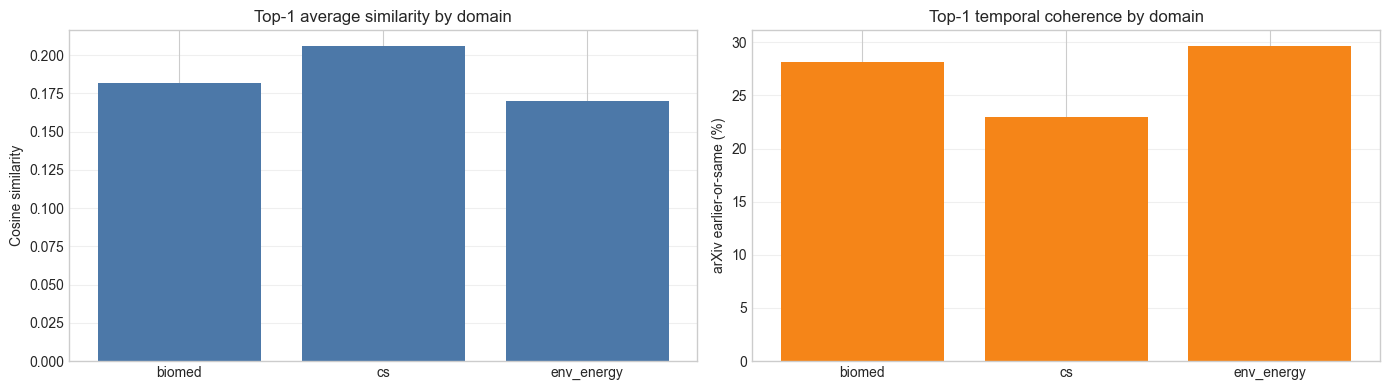

In [30]:
baseline_eval_plot = baseline_domain_summary_view.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(baseline_eval_plot['domain'], baseline_eval_plot['top1_avg_similarity'], color='#4C78A8')
axes[0].set_title('Top-1 average similarity by domain')
axes[0].set_ylabel('Cosine similarity')
axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(baseline_eval_plot['domain'], baseline_eval_plot['top1_arxiv_earlier_pct'], color='#F58518')
axes[1].set_title('Top-1 temporal coherence by domain')
axes[1].set_ylabel('arXiv earlier-or-same (%)')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 结果说明：baseline 的第一层评估

这里先不用人工标注，就能做一个最基础的 baseline 检查。左图看的是 lexical matcher 在各 domain 上抓到的平均相似度强弱；右图看的是高分 pair 是否在时间上大体符合“论文先于资助需求公开”的方向。

当前图形反映出一个很关键的事实：`cs` 域虽然平均相似度最高，但它的 `top1` 时间一致性最低，仅 `22.97%`；`env_energy` 的时间一致性最高，也只有 `29.63%`。换句话说，原始文本 TF-IDF baseline 已经足以作为检索起点，但还远不足以支撑后续时滞研究的直接结论。下一步必须进入误差分析，重点检查高分 pair 为什么在时间上大量“倒挂”，以及这种倒挂究竟来自公告腔、论文腔，还是候选池过宽。

## 8. 阶段性判断

基于当前这一版 notebook，可以得出四个更明确的阶段性判断：
1. EDA 部分已经足够支撑“数据概况 + 字段质量 + pilot 设计 + 风格差异 + matching readiness”这一整节内容。
2. 侧别停用词目前已经进入“候选发现”阶段，而且候选词呈现出明显的两侧文体差异，但它们还没有被提前注入 baseline，这保证了原始文本 baseline 仍然是一个清晰可对照的起点。
3. 原始文本 TF-IDF baseline 现在已经按 domain 建立并落库，共生成 `1,444,300` 条 top-20 匹配结果，可以支持后续评估、误差分析与人工核验。
4. 但这份 baseline 也明确暴露了当前瓶颈：虽然 `top1_avg_similarity` 已经达到 `0.1698-0.2059`，但 `top1_arxiv_earlier_pct` 只有 `22.97%-29.63%`，说明它还不能直接作为时序分析依据。因此，`baseline` 分支还应继续，下一步最合理的工作是基于当前基线结果做误差分析，并据此构造第一版定制停用词表。